
--- Información general ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   edad          200 non-null    int64  
 1   genero        200 non-null    object 
 2   visitas       200 non-null    int64  
 3   compras       200 non-null    int64  
 4   gasto_total   194 non-null    float64
 5   devoluciones  200 non-null    int64  
 6   reseñas       200 non-null    int64  
dtypes: float64(1), int64(5), object(1)
memory usage: 11.1+ KB
None

--- Primeras filas ---
   edad     genero  visitas  compras  gasto_total  devoluciones  reseñas
0    56   Femenino        8       10      14809.0             1        3
1    69   Femenino       27       11     173273.0             3        1
2    46  Masculino       27       12     194402.0             0        5
3    32  Masculino       34       11     154528.0             0        5
4    60   Femenino     

/tmp/ipykernel_278/1446773376.py:53: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["gasto_total"].fillna(df["gasto_total"].mean(), inplace=True)


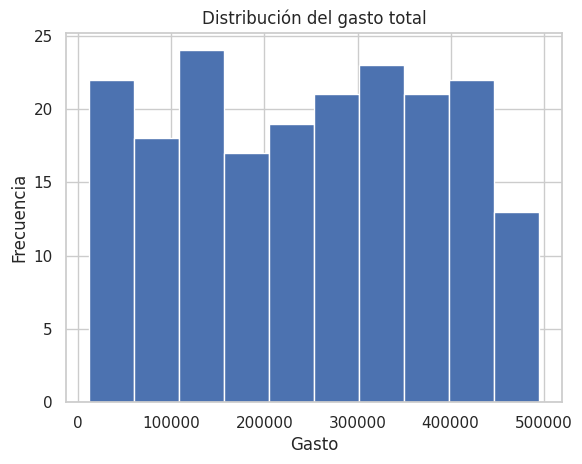

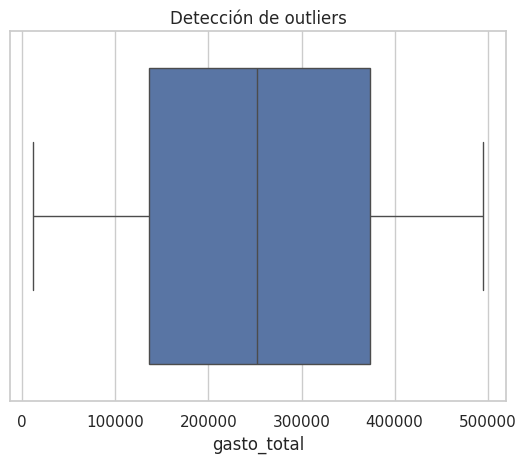

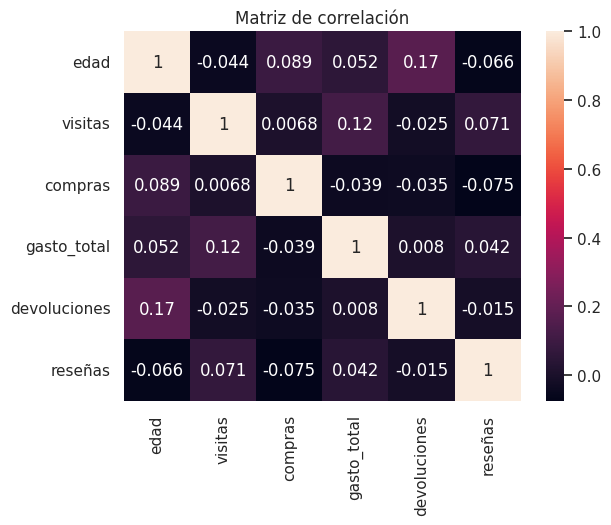

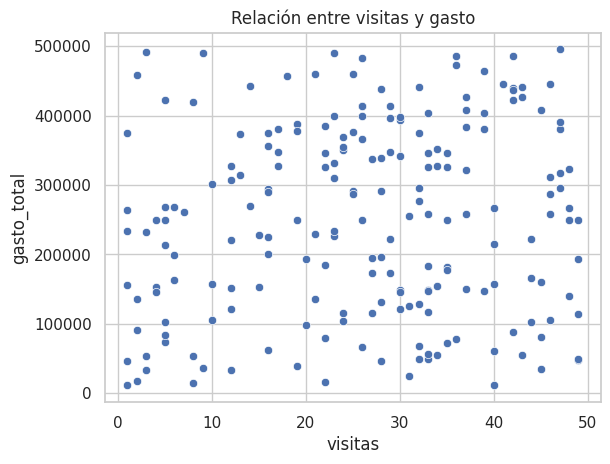


--- Resumen del modelo ---
                            OLS Regression Results                            
Dep. Variable:            gasto_total   R-squared:                       0.013
Model:                            OLS   Adj. R-squared:                  0.008
Method:                 Least Squares   F-statistic:                     2.677
Date:                Wed, 18 Mar 2026   Prob (F-statistic):              0.103
Time:                        01:05:46   Log-Likelihood:                -2647.9
No. Observations:                 200   AIC:                             5300.
Df Residuals:                     198   BIC:                             5306.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       2.201e+05   

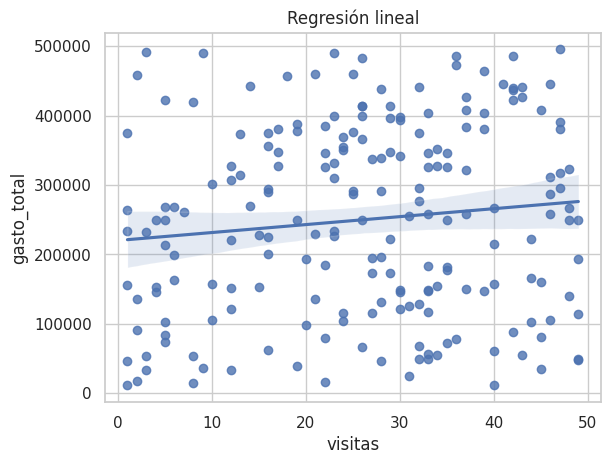

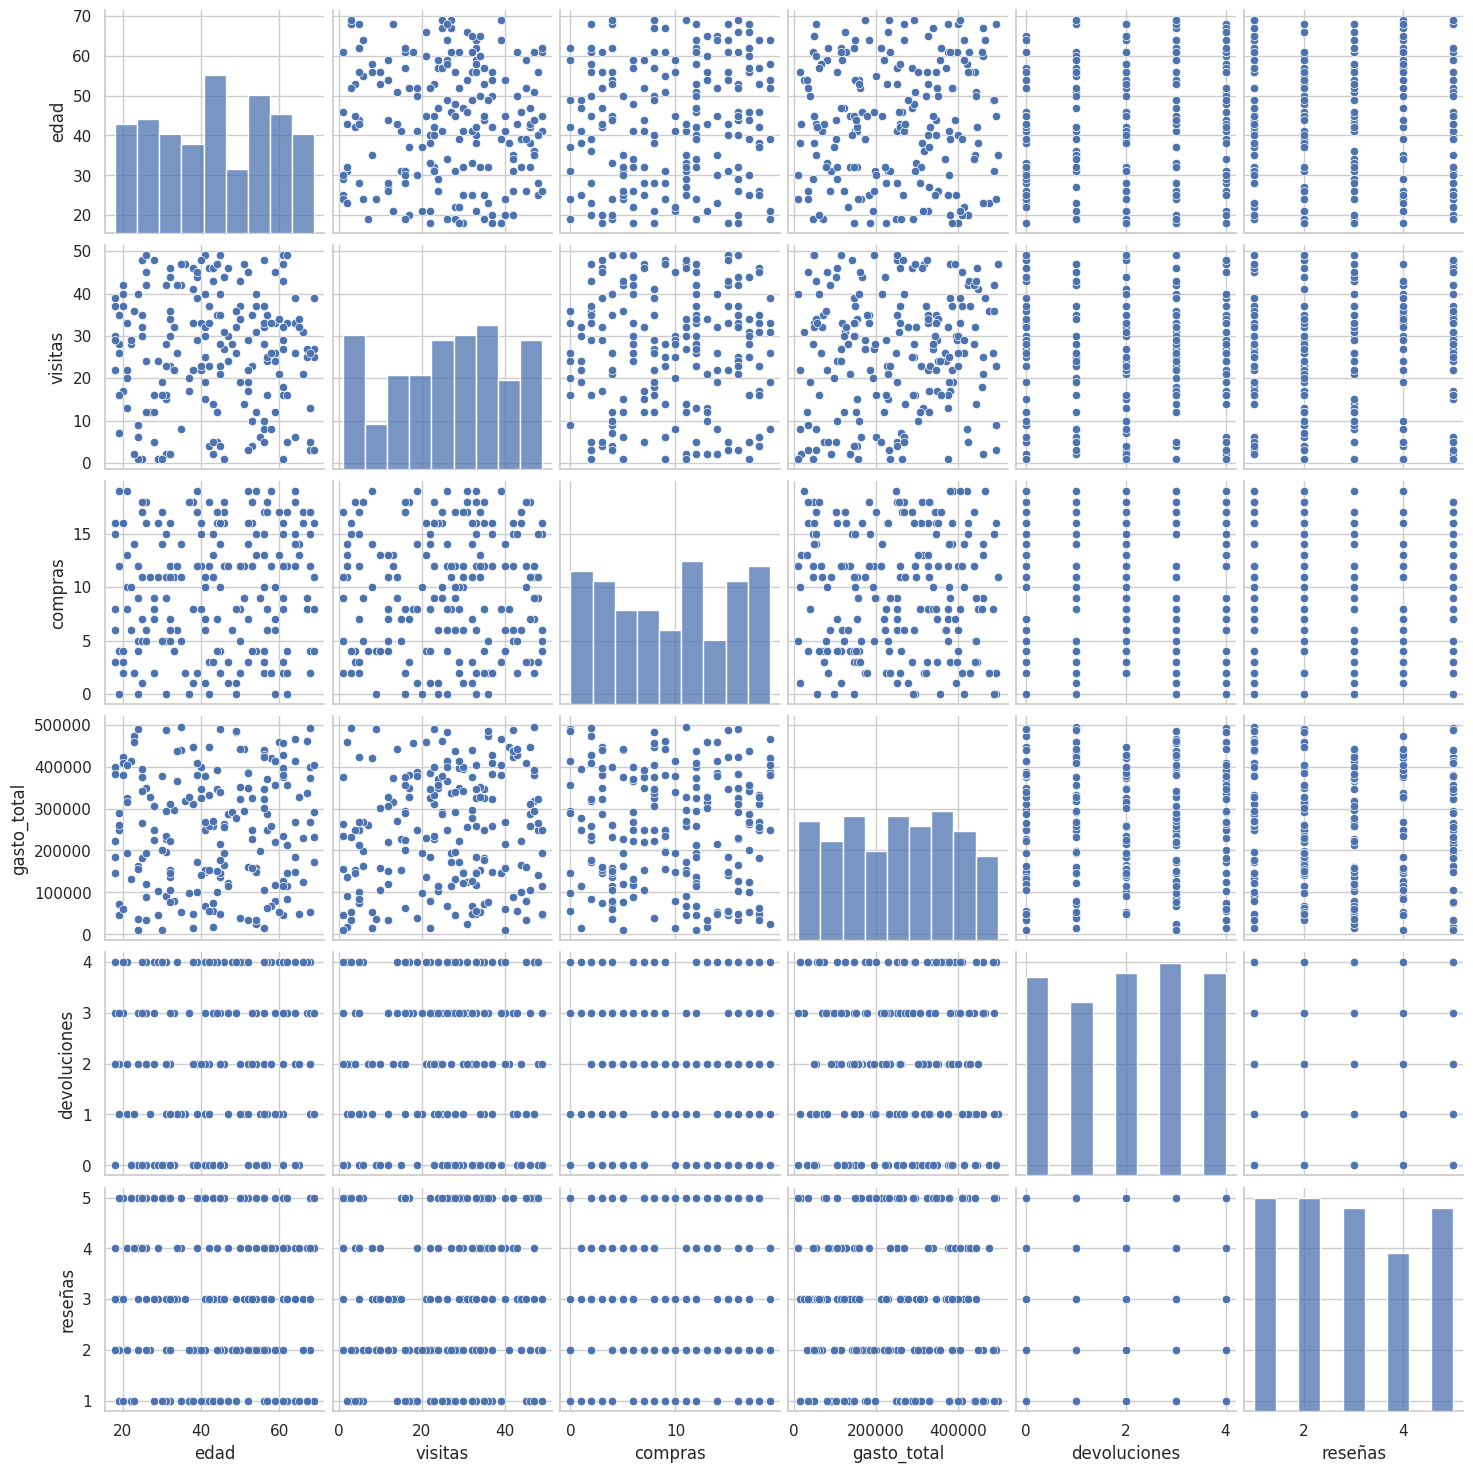

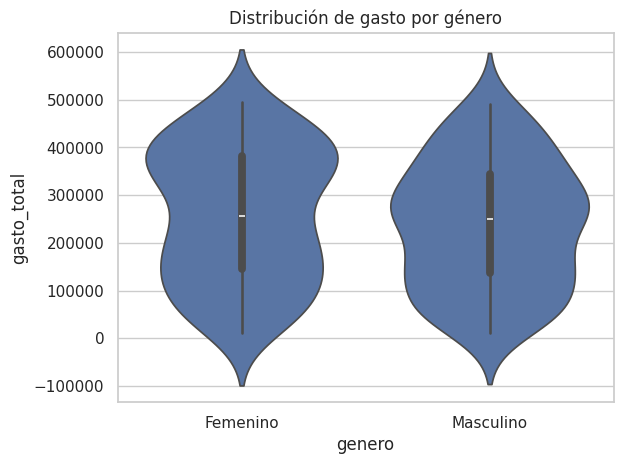

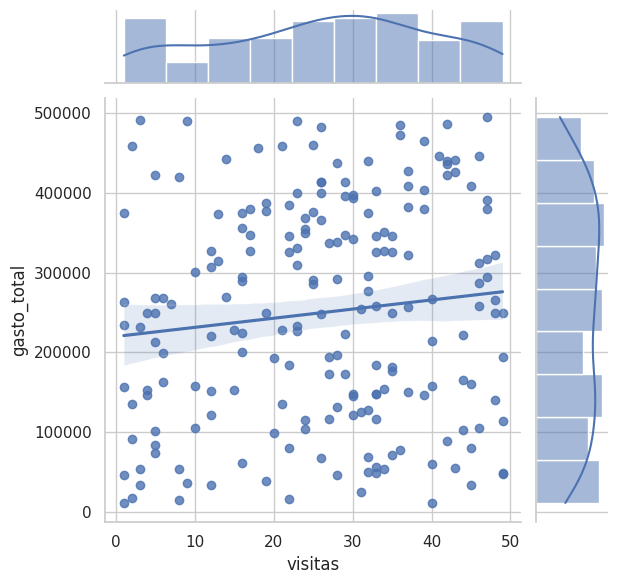


Proceso finalizado correctamente ✅


In [7]:
# =========================================
# PROYECTO: ANÁLISIS EXPLORATORIO DE DATOS
# Empresa: ComercioYA
# =========================================

# -----------------------------
# 1. IMPORTACIÓN DE LIBRERÍAS
# -----------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# Configuración visual
sns.set(style="whitegrid")

# -----------------------------
# 2. GENERACIÓN DEL DATASET
# -----------------------------
np.random.seed(42)
n = 200

df = pd.DataFrame({
    "edad": np.random.randint(18, 70, n),
    "genero": np.random.choice(["Masculino", "Femenino"], n),
    "visitas": np.random.randint(1, 50, n),
    "compras": np.random.randint(0, 20, n),
    "gasto_total": np.random.randint(10000, 500000, n),
    "devoluciones": np.random.randint(0, 5, n),
    "reseñas": np.random.randint(1, 6, n)
})

# Introducir valores nulos para análisis realista
df.loc[10:15, "gasto_total"] = np.nan

# -----------------------------
# 3. ANÁLISIS EXPLORATORIO (EDA)
# -----------------------------
print("\n--- Información general ---")
print(df.info())

print("\n--- Primeras filas ---")
print(df.head())

print("\n--- Valores nulos ---")
print(df.isnull().sum())

# -----------------------------
# 4. LIMPIEZA DE DATOS
# -----------------------------
# Imputación con la media
df["gasto_total"].fillna(df["gasto_total"].mean(), inplace=True)

# -----------------------------
# 5. ESTADÍSTICA DESCRIPTIVA
# -----------------------------
print("\n--- Estadísticas descriptivas ---")
print(df.describe())

# -----------------------------
# 6. VISUALIZACIONES BÁSICAS
# -----------------------------

# Histograma
plt.figure()
plt.hist(df["gasto_total"])
plt.title("Distribución del gasto total")
plt.xlabel("Gasto")
plt.ylabel("Frecuencia")
plt.savefig("histograma_gasto.png")
plt.show()

# Boxplot (outliers)
plt.figure()
sns.boxplot(x=df["gasto_total"])
plt.title("Detección de outliers")
plt.savefig("boxplot_gasto.png")
plt.show()

# -----------------------------
# 7. CORRELACIÓN
# -----------------------------
corr = df.corr(numeric_only=True)

plt.figure()
sns.heatmap(corr, annot=True)
plt.title("Matriz de correlación")
plt.savefig("heatmap.png")
plt.show()

# Scatterplot
plt.figure()
sns.scatterplot(x="visitas", y="gasto_total", data=df)
plt.title("Relación entre visitas y gasto")
plt.savefig("scatter.png")
plt.show()

# -----------------------------
# 8. REGRESIÓN LINEAL
# -----------------------------
X = df["visitas"]
y = df["gasto_total"]

X = sm.add_constant(X)

modelo = sm.OLS(y, X).fit()

print("\n--- Resumen del modelo ---")
print(modelo.summary())

# Visualización regresión
plt.figure()
sns.regplot(x="visitas", y="gasto_total", data=df)
plt.title("Regresión lineal")
plt.savefig("regresion.png")
plt.show()

# -----------------------------
# 9. VISUALIZACIÓN AVANZADA
# -----------------------------

# Pairplot
sns.pairplot(df)
plt.savefig("pairplot.png")
plt.show()

# Violinplot
plt.figure()
sns.violinplot(x="genero", y="gasto_total", data=df)
plt.title("Distribución de gasto por género")
plt.savefig("violinplot.png")
plt.show()

# Jointplot
sns.jointplot(x="visitas", y="gasto_total", data=df, kind="reg")
plt.savefig("jointplot.png")
plt.show()

# -----------------------------
# 10. EXPORTACIÓN DE DATOS
# -----------------------------
df.to_csv("dataset_final.csv", index=False)

print("\nProceso finalizado correctamente")